# 3. Evaluation

Scored on the combined dataset's test split: 593 photos with 870 fruit, including 170 photos with no fruit at all, used neither for training nor for picking the best epoch.

In [1]:
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path[:0] = [os.getcwd(), "notebooks"]

import json
import random
import subprocess

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from ultralytics import YOLO

import viz
from dataset_stats import list_images, load_dataset

viz.setup()
DATA6, DATA3 = "datasets/combined/data.yaml", "datasets/combined-3class/data.yaml"
model = YOLO("models/fruit-6class.pt")
test = model.val(data=DATA6, split="test", batch=32, project="runs/val", name="test6", exist_ok=True)

Ultralytics 8.3.234  Python-3.13.1 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
YOLOv12n summary (fused): 159 layers, 2,557,898 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 200.673.5 MB/s, size: 37.4 KB)
val: Scanning datasets\combined\test\labels.cache... 593 images, 170 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 593/593 1.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 5.6it/s 3.4s
                   all        593        870      0.966      0.972      0.986      0.885
          rotten_apple         87        112      0.979          1      0.995      0.933
         rotten_banana         86        167      0.929      0.936      0.964      0.775
         rotten_orange         74        142      0.977      0.993      0.995      0.923
           fresh_apple         65         89      0.954      0.966      0.978      0.911
          fresh_banana         75   

In [2]:
model3 = YOLO("models/fruit-3class.pt")
rows = {}
for label, m, data, split in (("6 classes, validation", model, DATA6, "val"), ("6 classes, test", model, DATA6, "test"),
                              ("3 classes, validation", model3, DATA3, "val"), ("3 classes, test", model3, DATA3, "test")):
    r = test if label == "6 classes, test" else m.val(data=data, split=split, batch=32, plots=False, verbose=False,
                                                      project="runs/val", name=label.replace(", ", "_").replace(" ", ""), exist_ok=True)
    rows[label] = {"fruit": int(r.nt_per_class.sum()), "precision": r.box.mp, "recall": r.box.mr,
                   "mAP@50": r.box.map50, "mAP@50-95": r.box.map}
pd.DataFrame(rows).T.round(3).astype({"fruit": int})

Ultralytics 8.3.234  Python-3.13.1 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 258.6161.2 MB/s, size: 44.7 KB)
val: Scanning datasets\combined\valid\labels.cache... 991 images, 144 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 991/991 1.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 6.0it/s 5.1s
                   all        991       1758      0.973      0.971       0.99      0.889
Speed: 0.8ms preprocess, 1.7ms inference, 0.0ms loss, 0.9ms postprocess per image
Ultralytics 8.3.234  Python-3.13.1 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
YOLOv12n summary (fused): 159 layers, 2,557,313 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 203.3123.0 MB/s, size: 49.5 KB)
val: Scanning datasets\combined-3class\val\labels.cache... 991 images, 144 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 991/991 1.4Mit/

,fruit,precision,recall,mAP@50,mAP@50-95
"6 classes, validation",1758,0.973,0.971,0.990,0.889
"6 classes, test",870,0.966,0.972,0.986,0.885
"3 classes, validation",1758,0.981,0.983,0.990,0.882
"3 classes, test",870,0.975,0.978,0.989,0.880


## Per class (6-class model)

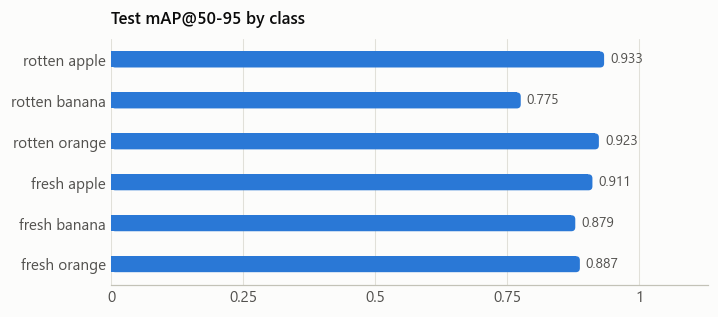

,Images,Instances,Box-P,Box-R,mAP50,mAP50-95
Class,,,,,,
rotten_apple,87,112,0.979,1.000,0.995,0.933
rotten_banana,86,167,0.929,0.936,0.964,0.775
rotten_orange,74,142,0.977,0.993,0.995,0.923
fresh_apple,65,89,0.954,0.966,0.978,0.911
fresh_banana,75,201,0.969,0.960,0.991,0.879
fresh_orange,71,159,0.987,0.975,0.994,0.887


In [3]:
per_class = pd.DataFrame(test.summary()).set_index("Class")[["Images", "Instances", "Box-P", "Box-R", "mAP50", "mAP50-95"]]
fig, ax = plt.subplots(figsize=(7, 2.9))
viz.hbars(ax, [c.replace("_", " ") for c in per_class.index], per_class["mAP50-95"].to_numpy(), fmt="{:.3f}", xmax=1.13)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1], ["0", "0.25", "0.5", "0.75", "1"])
ax.set_title("Test mAP@50-95 by class")
viz.render(fig)
per_class.round(3)

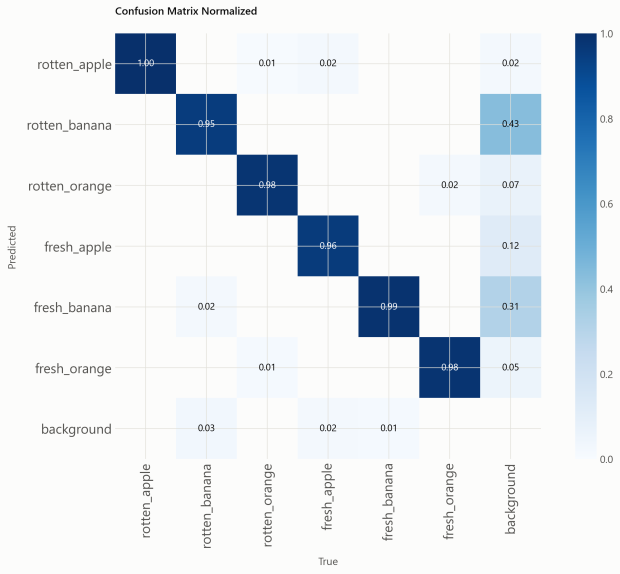

In [4]:
viz.show(Path(test.save_dir) / "confusion_matrix_normalized.png", width=620, fmt="png")

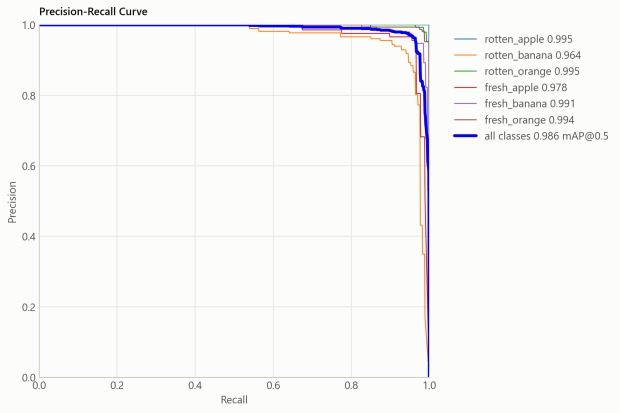

In [5]:
viz.show(Path(test.save_dir) / "BoxPR_curve.png", width=620, fmt="png")

## Predictions

Random test photos with every box the model draws at the default 0.25 confidence:

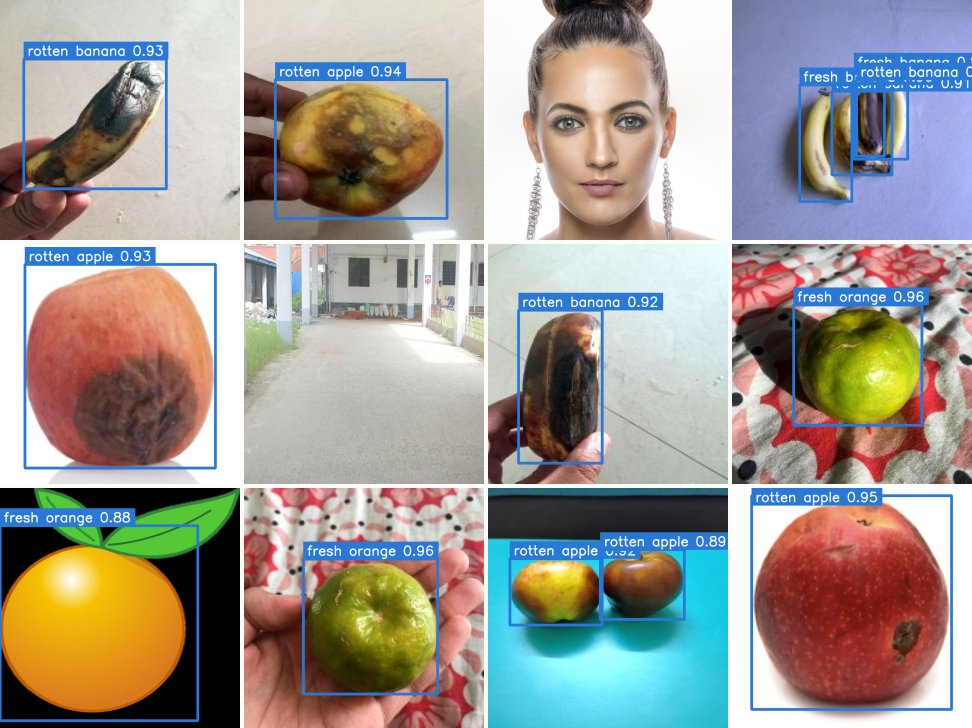

In [6]:
splits, names = load_dataset(DATA6)
test_images = list_images(splits["test"])


def truth(img_path):
    lines = (img_path.parent.parent / "labels" / f"{img_path.stem}.txt").read_text().splitlines()
    return [(int(c), np.array(box, float)) for c, *box in (l.split() for l in lines if l.strip())]


def draw(img_path, r, with_truth=False):
    img = cv2.imread(str(img_path))
    H, W = img.shape[:2]
    if with_truth:
        for _, box in truth(img_path):
            viz.draw_box(img, viz.yolo_to_xyxy(box, W, H), viz.ORANGE)
    for (x1, y1, x2, y2), c, conf in zip(r.boxes.xyxy.tolist(), r.boxes.cls.int().tolist(), r.boxes.conf.tolist()):
        viz.draw_box(img, (x1, y1, x2, y2), viz.BLUE, f"{names[c].replace('_', ' ')} {conf:.2f}")
    return img


def predict_all(paths, batch=32):
    """Predict in chunks. A plain list passed to predict() is loaded and run as one giant batch."""
    for i in range(0, len(paths), batch):
        yield from model.predict(paths[i:i + batch], verbose=False)


random.seed(0)
picks = random.sample(test_images, 12)
viz.grid([draw(p, r) for p, r in zip(picks, predict_all(picks))], cols=4, tile=240)

## Mistakes

Each predicted box is matched to an unmatched true box of IoU 0.5 or more. What is left over counts as a mistake: a true fruit with no match (missed), a match with the wrong class, or a predicted box with no fruit under it (extra), split by whether the photo has fruit at all.

In [7]:
def iou(a, b):
    a1, a2, b1, b2 = a[:2] - a[2:] / 2, a[:2] + a[2:] / 2, b[:2] - b[2:] / 2, b[:2] + b[2:] / 2
    inter = np.clip(np.minimum(a2, b2) - np.maximum(a1, b1), 0, None).prod()
    return inter / (a[2:].prod() + b[2:].prod() - inter)


totals = {"true fruit": 0, "found, right class": 0, "found, wrong class": 0, "missed": 0,
          "extra box on a fruit photo": 0, "extra box on a no-fruit photo": 0}
per_image = []
for img_path, r in zip(test_images, predict_all(test_images)):
    gt, used, wrong, extra = truth(img_path), set(), 0, 0
    for c, box in zip(r.boxes.cls.int().tolist(), r.boxes.xywhn.cpu().numpy()):  # highest confidence first
        scores = [(iou(box, g), j) for j, (_, g) in enumerate(gt) if j not in used]
        best = max(scores, default=(0, None))
        if best[0] >= 0.5:
            used.add(best[1])
            wrong += gt[best[1]][0] != c
        else:
            extra += 1
    totals["true fruit"] += len(gt)
    totals["found, right class"] += len(used) - wrong
    totals["found, wrong class"] += wrong
    totals["missed"] += len(gt) - len(used)
    totals["extra box on a fruit photo" if gt else "extra box on a no-fruit photo"] += extra
    per_image.append((img_path, r, wrong + len(gt) - len(used) + extra))

pd.Series(totals, name="boxes").to_frame()

,boxes
true fruit,870
"found, right class",846
"found, wrong class",10
missed,14
extra box on a fruit photo,58
extra box on a no-fruit photo,5


Only 5 extra boxes land on the 170 photos without fruit, so the face and scene photos did their job. The test photos with the most mistakes are mostly tight bunches of bananas, where the true boxes overlap and the model merges or splits them. Orange is the true box, blue the model's:

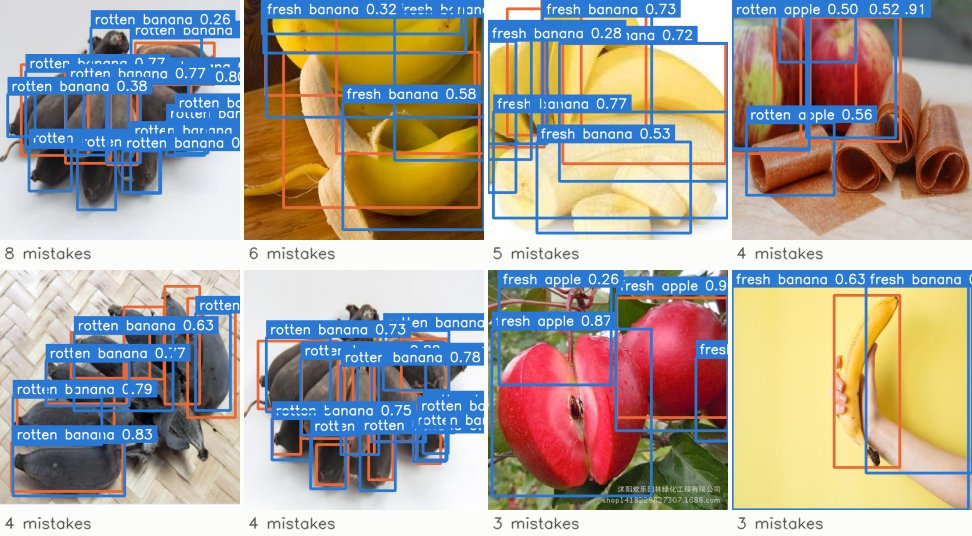

In [8]:
worst = sorted(per_image, key=lambda t: -t[2])[:8]
viz.grid([draw(p, r, with_truth=True) for p, r, _ in worst], [f"{n} mistakes" for *_, n in worst], cols=4, tile=240)

## OpenVINO

`export.py` converts the weights to OpenVINO IR with a fixed 1x3x640x640 input, which the NPU requires. Given the same input, both runtimes should produce the same output:

In [9]:
import openvino as ov
import torch

OV = Path("models/fruit-6class_openvino_model")
if not OV.exists():
    subprocess.run([sys.executable, "export.py"], check=True)
x = torch.rand(1, 3, 640, 640)
with torch.no_grad():
    y_pt = YOLO("models/fruit-6class.pt").model.float().eval()(x)[0].numpy()
y_ov = ov.Core().compile_model(next(OV.glob("*.xml")), "CPU")(x.numpy())[0]
print(f"largest difference between PyTorch and OpenVINO outputs: {np.abs(y_pt - y_ov).max():.4f} "
      f"(box coordinates are in pixels, 0-640)")

largest difference between PyTorch and OpenVINO outputs: 0.0013 (box coordinates are in pixels, 0-640)


And the same test score, with both fed a fixed 640x640 input. The headline numbers above use Ultralytics' default rectangular batches, which pad the photos to 672x672, so they differ slightly.

In [10]:
pt_640 = model.val(data=DATA6, split="test", batch=32, rect=False, plots=False, verbose=False,
                   project="runs/val", name="test6_640", exist_ok=True)
ov_640 = YOLO(OV, task="detect").val(data=DATA6, split="test", device="intel:cpu", plots=False, verbose=False,
                                     project="runs/val", name="test6_openvino", exist_ok=True)
pd.DataFrame({"PyTorch (RTX 3090)": [pt_640.box.map50, pt_640.box.map], "OpenVINO (CPU)": [ov_640.box.map50, ov_640.box.map]},
             index=["mAP@50", "mAP@50-95"]).round(4)

Ultralytics 8.3.234  Python-3.13.1 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 246.548.8 MB/s, size: 38.8 KB)
val: Scanning datasets\combined\test\labels.cache... 593 images, 170 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 593/593 1.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 7.3it/s 2.6s
                   all        593        870      0.955      0.973      0.986      0.876
Speed: 0.7ms preprocess, 1.7ms inference, 0.0ms loss, 0.7ms postprocess per image
Loading models\fruit-6class_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on CPU...
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access  (ping: 0.00.0 ms, read: 272.487.4 MB/s, size: 47.9 KB)
val: Scanning datasets\combined\test\labels.cache... 593 images, 170 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 593/593 855.0Kit/s 0.0s
   

,PyTorch (RTX 3090),OpenVINO (CPU)
mAP@50,0.9860,0.9860
mAP@50-95,0.8763,0.8763


## Speed

Measured on the laptop the webcam demo runs on, with `python demo.py --benchmark 300 --device intel:<npu|gpu|cpu>`: 300 inferences on a 640x480 frame after warm-up, batch 1.

In [11]:
bench = {p.stem.split("_")[-1].upper(): json.loads(p.read_text()) for p in sorted(Path("results").glob("benchmark_intel_*.json"))}
if bench:
    speed = pd.DataFrame({dev: {"chip": b["device_name"], "ran on": ", ".join(b["execution_devices"] or []),
                                "inference (ms)": b["mean_ms"]["inference"], "inference FPS": b["inference_fps"],
                                "pre + inference + NMS FPS": b["pipeline_fps"]} for dev, b in bench.items()}).T
    print("host:", next(iter(bench.values()))["host_cpu"])
    display(speed)
    order = speed.sort_values("inference FPS", ascending=False)
    fig, ax = plt.subplots(figsize=(7, 1.9))
    viz.hbars(ax, list(order.index), order["inference FPS"].astype(float).to_numpy(), fmt="{:.0f} FPS",
              colors=[viz.BLUE if d == "NPU" else viz.CONTEXT for d in order.index])
    ax.set_title("Inference speed by device")
    viz.render(fig)
else:
    print("no results/benchmark_intel_*.json yet - run demo.py --benchmark on the laptop")

no results/benchmark_intel_*.json yet - run demo.py --benchmark on the laptop
